In [5]:
# Kerakli kutubxonalarni chaqirib, CSV faylni yuklayapman va TotalCharges ustunini raqamga aylantiryapman
import pandas as pd
import matplotlib.pyplot as plt
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

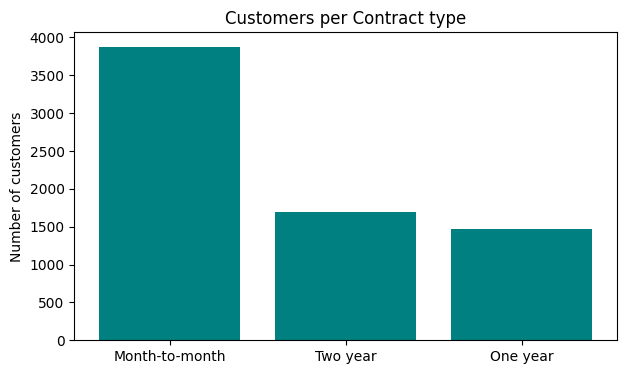

In [6]:
# Har bir shartnoma turidan nechta mijoz borligini sanab, ustunli diagramma qilib chizayapman
counts = df['Contract'].value_counts()
plt.figure(figsize=(7, 4))
plt.bar(counts.index, counts.values, color='teal')
plt.title('Customers per Contract type')
plt.ylabel('Number of customers')
plt.show()

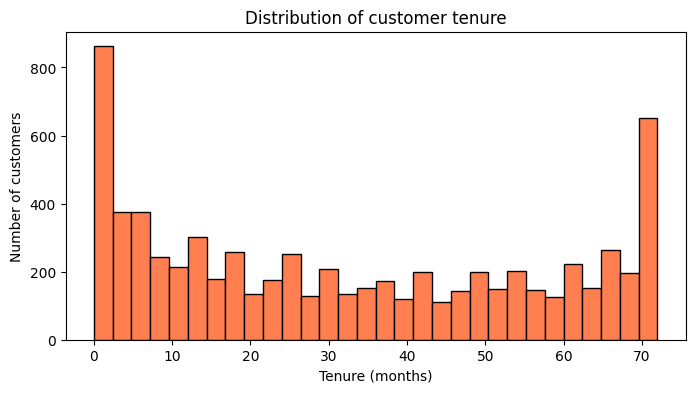

In [7]:
# Mijozlarning xizmatda bo'lgan oylar soni (tenure) qanday taqsimlanganini gistogramma orqali ko'rsatayapman
plt.figure(figsize=(8, 4))
plt.hist(df['tenure'], bins=30, color='coral', edgecolor='black')
plt.title('Distribution of customer tenure')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of customers')
plt.show()

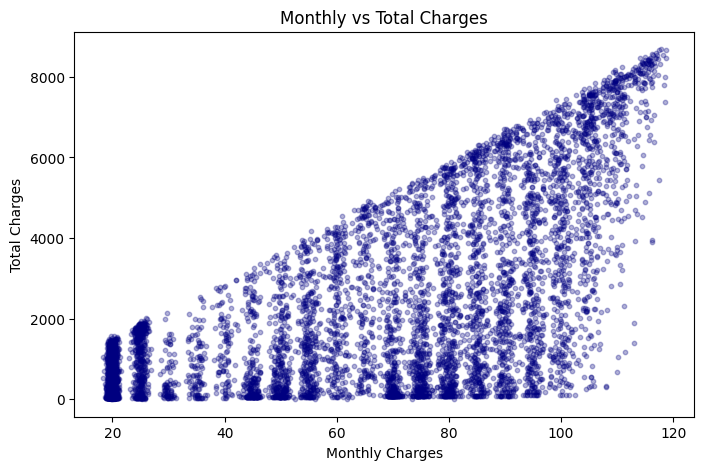

In [8]:
# Oylik to'lov bilan umumiy to'lov orasidagi bog'liqlikni scatter plot orqali tekshirayapman
plt.figure(figsize=(8, 5))
plt.scatter(df['MonthlyCharges'], df['TotalCharges'], alpha=0.3, s=10, color='navy')
plt.title('Monthly vs Total Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Total Charges')
plt.show()

/tmp/ipykernel_2542/197736311.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels)


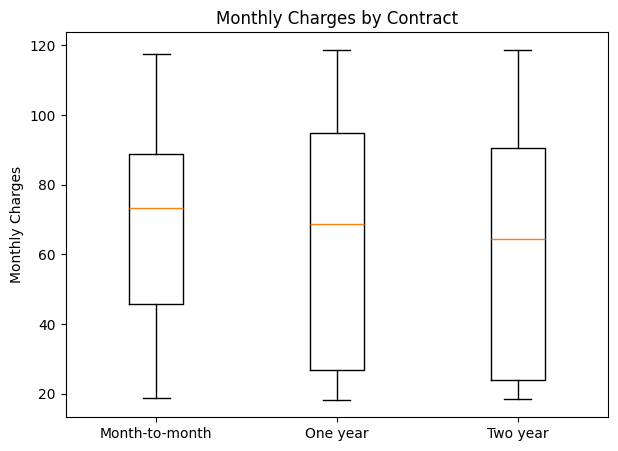

In [9]:
# Har bir shartnoma turi uchun oylik to'lovlarning taqsimotini box plot orqali solishtirayapman
groups = [df[df['Contract'] == c]['MonthlyCharges'] for c in df['Contract'].unique()]
labels = df['Contract'].unique()
plt.figure(figsize=(7, 5))
plt.boxplot(groups, labels=labels)
plt.title('Monthly Charges by Contract')
plt.ylabel('Monthly Charges')
plt.show()

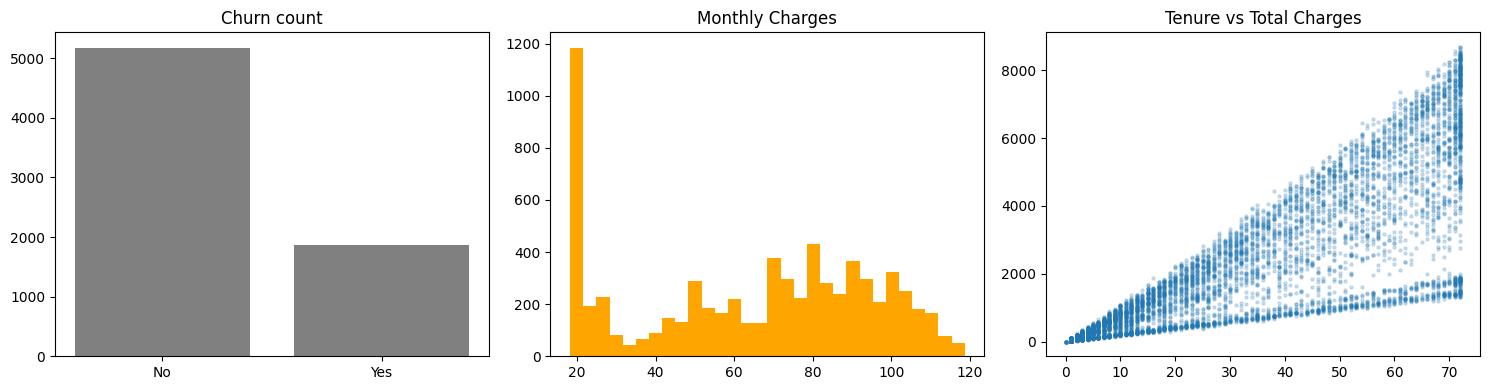

In [10]:
# Bitta katta rasmda 3 ta grafikni (churn soni, oylik to'lov taqsimoti, tenure vs umumiy to'lov) yonma-yon chizayapman
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].bar(df['Churn'].value_counts().index, df['Churn'].value_counts().values, color='gray')
ax[0].set_title('Churn count')
ax[1].hist(df['MonthlyCharges'], bins=30, color='orange')
ax[1].set_title('Monthly Charges')
ax[2].scatter(df['tenure'], df['TotalCharges'], alpha=0.2, s=5)
ax[2].set_title('Tenure vs Total Charges')
plt.tight_layout()
plt.show()